In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder 
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, LSTM, MaxPooling1D, GlobalAveragePooling1D, MaxPooling2D,Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tsfel

In [2]:
import DataLoader
path = r"C:\Users\willi\Desktop\PTBXL\\"

ecg_data, patient_data = DataLoader.loader(path)

ECG Data Shape: (21799, 1000, 12)
Patient Data Head:
        patient_id   age  sex  height  weight  nurse  site     device  \
ecg_id                                                                  
1          15709.0  56.0    1     NaN    63.0    2.0   0.0  CS-12   E   
2          13243.0  19.0    0     NaN    70.0    2.0   0.0  CS-12   E   
3          20372.0  37.0    1     NaN    69.0    2.0   0.0  CS-12   E   
4          17014.0  24.0    0     NaN    82.0    2.0   0.0  CS-12   E   
5          17448.0  19.0    1     NaN    70.0    2.0   0.0  CS-12   E   

             recording_date                                  report  ...  \
ecg_id                                                               ...   
1       1984-11-09 09:17:34  sinusrhythmus periphere niederspannung  ...   
2       1984-11-14 12:55:37     sinusbradykardie sonst normales ekg  ...   
3       1984-11-15 12:49:10              sinusrhythmus normales ekg  ...   
4       1984-11-15 13:44:57              sinusrhythmus 

In [3]:
patient_data['class'].value_counts()

class
[NORM]                 9069
[MI]                   2532
[STTC]                 2400
[CD]                   1708
[MI, CD]               1297
[HYP, STTC]             781
[STTC, MI]              599
[HYP]                   535
[STTC, CD]              471
[]                      411
[NORM, CD]              407
[HYP, STTC, MI]         361
[HYP, CD]               300
[STTC, MI, CD]          223
[HYP, STTC, CD]         211
[HYP, MI]               183
[HYP, STTC, MI, CD]     156
[HYP, MI, CD]           117
[STTC, NORM]             28
[STTC, NORM, CD]          5
[HYP, NORM, CD]           2
[HYP, NORM]               2
[HYP, NORM, MI, CD]       1
Name: count, dtype: int64

In [4]:
import DataLoader
patient_data = DataLoader.map_classes(patient_data)
patient_data['mapped_class'].value_counts()

mapped_class
Normal ECG                9476
Myocardial Infarction     3829
ST/T Change               3726
Hypertrophy               2649
Conduction Disturbance    1708
Other                      411
Name: count, dtype: int64

In [5]:
patient_data['class'].value_counts()

class
[NORM]                 9069
[MI]                   2532
[STTC]                 2400
[CD]                   1708
[MI, CD]               1297
[HYP, STTC]             781
[STTC, MI]              599
[HYP]                   535
[STTC, CD]              471
[]                      411
[NORM, CD]              407
[HYP, STTC, MI]         361
[HYP, CD]               300
[STTC, MI, CD]          223
[HYP, STTC, CD]         211
[HYP, MI]               183
[HYP, STTC, MI, CD]     156
[HYP, MI, CD]           117
[STTC, NORM]             28
[STTC, NORM, CD]          5
[HYP, NORM, CD]           2
[HYP, NORM]               2
[HYP, NORM, MI, CD]       1
Name: count, dtype: int64

In [6]:
import pandas as pd
df = pd.DataFrame()


df['ecg_signal'] = list(ecg_data)
df['diagnosis'] = patient_data['mapped_class'].values
df['age'] = patient_data['age'].values
df['strat_fold'] = patient_data['strat_fold'].values
df = df[(df['age'] <= 100) & (df['age'] >= 18)]
df



,ecg_signal,diagnosis,age,strat_fold
0,"[[-0.119, -0.055, 0.064, 0.086, -0.091, 0.004,...",Normal ECG,56.0,3
1,"[[0.004, 0.138, 0.134, -0.072, -0.065, 0.136, ...",Normal ECG,19.0,2
2,"[[-0.029, -0.079, -0.049, 0.054, 0.011, -0.064...",Normal ECG,37.0,5
3,"[[-0.054, -0.138, -0.083, 0.096, 0.015, -0.11,...",Normal ECG,24.0,3
4,"[[-0.034, -0.574, -0.54, 0.304, 0.253, -0.556,...",Normal ECG,19.0,4
...,...,...,...,...
21793,"[[-0.076, -0.029, 0.046, 0.052, -0.061, 0.008,...",Conduction Disturbance,63.0,7
21794,"[[-0.052, -0.034, 0.018, 0.043, -0.034, -0.008...",ST/T Change,67.0,7
21796,"[[0.038, 0.024, -0.014, -0.03, 0.026, 0.005, 0...",ST/T Change,59.0,2
21797,"[[-0.057, -0.057, 0.0, 0.057, -0.028, -0.028, ...",Normal ECG,64.0,8


In [7]:
df.drop(columns='age', inplace=True)
df = df[df['diagnosis'] != 'Other']
df

,ecg_signal,diagnosis,strat_fold
0,"[[-0.119, -0.055, 0.064, 0.086, -0.091, 0.004,...",Normal ECG,3
1,"[[0.004, 0.138, 0.134, -0.072, -0.065, 0.136, ...",Normal ECG,2
2,"[[-0.029, -0.079, -0.049, 0.054, 0.011, -0.064...",Normal ECG,5
3,"[[-0.054, -0.138, -0.083, 0.096, 0.015, -0.11,...",Normal ECG,3
4,"[[-0.034, -0.574, -0.54, 0.304, 0.253, -0.556,...",Normal ECG,4
...,...,...,...
21793,"[[-0.076, -0.029, 0.046, 0.052, -0.061, 0.008,...",Conduction Disturbance,7
21794,"[[-0.052, -0.034, 0.018, 0.043, -0.034, -0.008...",ST/T Change,7
21796,"[[0.038, 0.024, -0.014, -0.03, 0.026, 0.005, 0...",ST/T Change,2
21797,"[[-0.057, -0.057, 0.0, 0.057, -0.028, -0.028, ...",Normal ECG,8


In [8]:
!python -m pip install xgboost

In [9]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

X = np.array(df['ecg_signal'].tolist())
y_labels = df['diagnosis'].to_numpy()

X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

le = LabelEncoder()
y_int = le.fit_transform(y_labels)
y = to_categorical(y_int)

train_mask = df['strat_fold'].isin([1,2,3,4,5,6,7,8])
val_mask = df['strat_fold'] == 9
test_mask = df['strat_fold'] == 10

X_train = X[train_mask]
X_val = X[val_mask]
X_test = X[test_mask]

y_train = y[train_mask]
y_val = y[val_mask]
y_test = y[test_mask]

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

X_train: (16761, 1000, 12) y_train: (16761, 5)
X_val: (2096, 1000, 12) y_val: (2096, 5)
X_test: (2113, 1000, 12) y_test: (2113, 5)


In [18]:
import tensorflow as tf
from tensorflow.keras import layers, models

timesteps = X_train.shape[1]
channels  = X_train.shape[2]
n_classes = y_train.shape[1]

model = models.Sequential([
    layers.Input(shape=(timesteps, channels)),

    layers.Conv1D(32, kernel_size=7, activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),

    layers.Conv1D(64, kernel_size=5, activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),

    layers.Conv1D(128, kernel_size=3, activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling1D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(n_classes, activation="softmax")
])


model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 1000, 32)       │         2,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 1000, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 500, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 500, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 500, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 250, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 250, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 250, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,781 (217.89 KB)

 Trainable params: 55,333 (216.14 KB)

 Non-trainable params: 448 (1.75 KB)

In [19]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=callbacks
)

Epoch 1/30
524/524 ━━━━━━━━━━━━━━━━━━━━ 21s 36ms/step - accuracy: 0.6395 - loss: 0.9525 - val_accuracy: 0.6670 - val_loss: 0.8931 - learning_rate: 0.0010
Epoch 2/30
524/524 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - accuracy: 0.6987 - loss: 0.8129 - val_accuracy: 0.6899 - val_loss: 0.8237 - learning_rate: 0.0010
Epoch 3/30
524/524 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.7123 - loss: 0.7683 - val_accuracy: 0.7137 - val_loss: 0.7653 - learning_rate: 0.0010
Epoch 4/30
524/524 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - accuracy: 0.7225 - loss: 0.7408 - val_accuracy: 0.7252 - val_loss: 0.7790 - learning_rate: 0.0010
Epoch 5/30
524/524 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - accuracy: 0.7292 - loss: 0.7201 - val_accuracy: 0.6975 - val_loss: 0.7823 - learning_rate: 0.0010
Epoch 6/30
524/524 ━━━━━━━━━━━━━━━━━━━━ 19s 36ms/step - accuracy: 0.7371 - loss: 0.7022 - val_accuracy: 0.7142 - val_loss: 0.7513 - learning_rate: 0.0010
Epoch 7/30
524/524 ━━━━━━━━━━━━━━━━━━━━ 19s 36ms/step - accuracy: 0.7450 - l

In [20]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_pred = model.predict(X_val).argmax(axis=1)
y_true = y_val.argmax(axis=1)

print(classification_report(y_true, y_pred, target_names=le.classes_))
print(confusion_matrix(y_true, y_pred))

66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
                        precision    recall  f1-score   support

Conduction Disturbance       0.62      0.48      0.54       163
           Hypertrophy       0.68      0.47      0.56       258
 Myocardial Infarction       0.63      0.58      0.60       349
            Normal ECG       0.79      0.93      0.85       940
           ST/T Change       0.65      0.62      0.64       386

              accuracy                           0.72      2096
             macro avg       0.67      0.61      0.64      2096
          weighted avg       0.71      0.72      0.71      2096

[[ 78   5  25  43  12]
 [ 22 121  23  55  37]
 [ 16  16 201  69  47]
 [  6   4  24 873  33]
 [  3  32  48  63 240]]


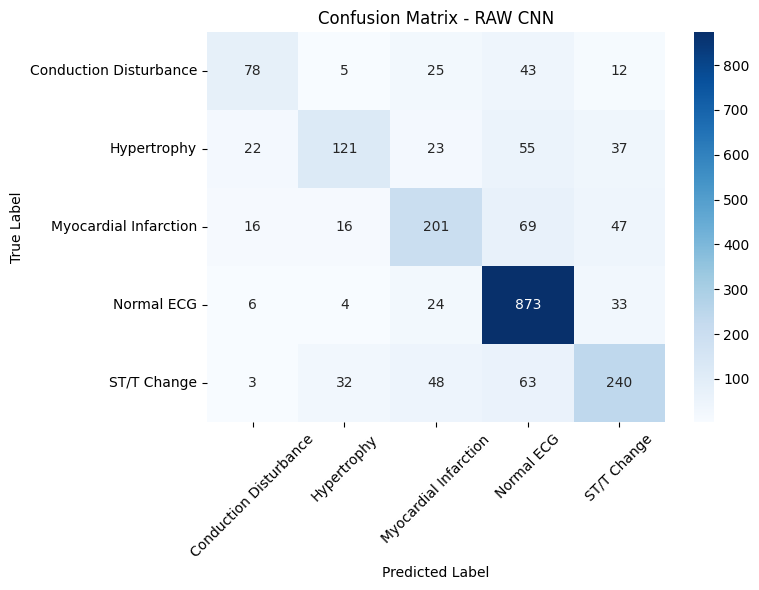

In [21]:
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_true, y_pred)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True, 
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - RAW CNN")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

CNN WITH SMOTE

In [22]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from imblearn.over_sampling import SMOTE

X = np.array(df['ecg_signal'].tolist())
y_labels = df['diagnosis'].to_numpy()

X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

le = LabelEncoder()
y_int = le.fit_transform(y_labels)
y = to_categorical(y_int)

train_mask = df['strat_fold'].isin([1,2,3,4,5,6,7,8])
val_mask = df['strat_fold'] == 9
test_mask = df['strat_fold'] == 10

X_train = X[train_mask]
X_val = X[val_mask]
X_test = X[test_mask]

y_train = y[train_mask]
y_val = y[val_mask]
y_test = y[test_mask]

y_train_int = y_int[train_mask]
y_val_int = y_int[val_mask]
y_test_int = y_int[test_mask]

print("Before SMOTE:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("y_train_int:", y_train_int.shape)

X_train_flat = X_train.reshape(X_train.shape[0], -1)

smote = SMOTE(random_state=42)
X_train_smote_flat, y_train_smote_int = smote.fit_resample(X_train_flat, y_train_int)

X_train_smote = X_train_smote_flat.reshape(-1, X.shape[1], X.shape[2])

y_train_smote = to_categorical(y_train_smote_int)

print("\nAfter SMOTE:")
print("X_train_smote:", X_train_smote.shape)
print("y_train_smote:", y_train_smote.shape)
print("y_train_smote_int:", y_train_smote_int.shape)

print("\nValidation set:")
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("\nTest set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Before SMOTE:
X_train: (16761, 1000, 12)
y_train: (16761, 5)
y_train_int: (16761,)

After SMOTE:
X_train_smote: (37230, 1000, 12)
y_train_smote: (37230, 5)
y_train_smote_int: (37230,)

Validation set:
X_val: (2096, 1000, 12)
y_val: (2096, 5)

Test set:
X_test: (2113, 1000, 12)
y_test: (2113, 5)


In [23]:
import tensorflow as tf
from tensorflow.keras import layers, models

timesteps = X_train.shape[1]
channels  = X_train.shape[2]
n_classes = y_train.shape[1]

model = models.Sequential([
    layers.Input(shape=(timesteps, channels)),

    layers.Conv1D(32, kernel_size=7, activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),

    layers.Conv1D(64, kernel_size=5, activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),

    layers.Conv1D(128, kernel_size=3, activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling1D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(n_classes, activation="softmax")
])


model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_9 (Conv1D)               │ (None, 1000, 32)       │         2,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 1000, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 500, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 500, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 500, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 250, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 250, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 250, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,781 (217.89 KB)

 Trainable params: 55,333 (216.14 KB)

 Non-trainable params: 448 (1.75 KB)

In [24]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5)
]

history = model.fit(
    X_train_smote,
    y_train_smote,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=callbacks
)

Epoch 1/30
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 43s 35ms/step - accuracy: 0.6738 - loss: 0.8598 - val_accuracy: 0.6574 - val_loss: 0.8806 - learning_rate: 0.0010
Epoch 2/30
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 41s 35ms/step - accuracy: 0.7607 - loss: 0.6435 - val_accuracy: 0.6780 - val_loss: 0.8741 - learning_rate: 0.0010
Epoch 3/30
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 40s 34ms/step - accuracy: 0.7849 - loss: 0.5716 - val_accuracy: 0.6923 - val_loss: 0.8353 - learning_rate: 0.0010
Epoch 4/30
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 43s 37ms/step - accuracy: 0.8017 - loss: 0.5290 - val_accuracy: 0.6918 - val_loss: 0.8030 - learning_rate: 0.0010
Epoch 5/30
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 41s 36ms/step - accuracy: 0.8141 - loss: 0.4965 - val_accuracy: 0.6923 - val_loss: 0.8251 - learning_rate: 0.0010
Epoch 6/30
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 40s 35ms/step - accuracy: 0.8195 - loss: 0.4768 - val_accuracy: 0.6789 - val_loss: 0.9024 - learning_rate: 0.0010
Epoch 7/30
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 41s 35ms/step - accura

66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
                        precision    recall  f1-score   support

Conduction Disturbance       0.59      0.56      0.57       163
           Hypertrophy       0.65      0.55      0.60       258
 Myocardial Infarction       0.62      0.52      0.57       349
            Normal ECG       0.80      0.91      0.85       940
           ST/T Change       0.63      0.59      0.61       386

              accuracy                           0.72      2096
             macro avg       0.66      0.63      0.64      2096
          weighted avg       0.71      0.72      0.71      2096



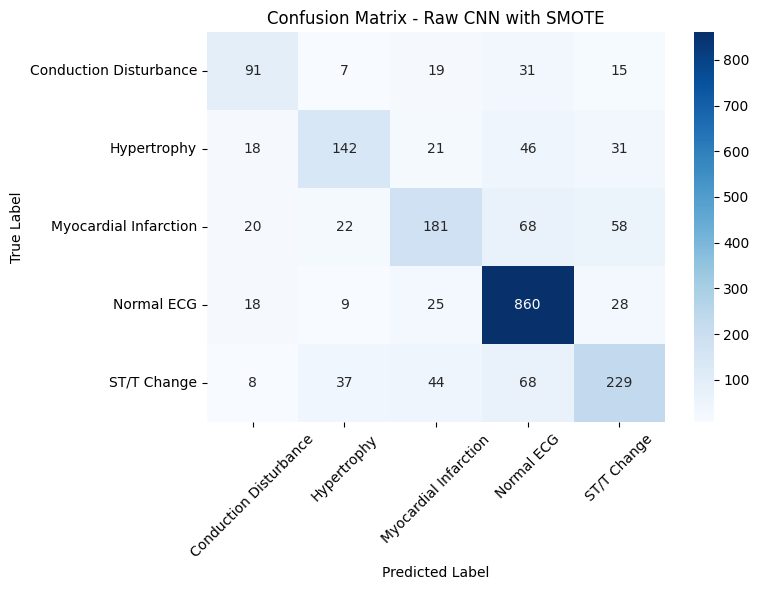

In [25]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_val).argmax(axis=1)
y_true = y_val.argmax(axis=1)

print(classification_report(y_true, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Raw CNN with SMOTE")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

DENSE MODEL


In [24]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

X = np.array(df['ecg_signal'].tolist())
y_labels = df['diagnosis'].to_numpy()

X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

le = LabelEncoder()
y_int = le.fit_transform(y_labels)
y = to_categorical(y_int)

train_mask = df['strat_fold'].isin([1,2,3,4,5,6,7,8])
val_mask = df['strat_fold'] == 9
test_mask = df['strat_fold'] == 10

X_train = X[train_mask]
X_val = X[val_mask]
X_test = X[test_mask]

y_train = y[train_mask]
y_val = y[val_mask]
y_test = y[test_mask]

X_train = X_train.reshape(X_train.shape[0], -1)
X_val = X_val.reshape(X_val.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

X_train: (16761, 12000) y_train: (16761, 5)
X_val: (2096, 12000) y_val: (2096, 5)
X_test: (2113, 12000) y_test: (2113, 5)


In [25]:
model = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(n_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 256)            │     3,072,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,105,797 (11.85 MB)

 Trainable params: 3,105,797 (11.85 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=callbacks
)

Epoch 1/30
524/524 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.4067 - loss: 1.5198 - val_accuracy: 0.4490 - val_loss: 1.4281 - learning_rate: 0.0010
Epoch 2/30
524/524 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.4732 - loss: 1.3486 - val_accuracy: 0.4599 - val_loss: 1.4036 - learning_rate: 0.0010
Epoch 3/30
524/524 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.5143 - loss: 1.2508 - val_accuracy: 0.4699 - val_loss: 1.4088 - learning_rate: 0.0010
Epoch 4/30
524/524 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.5565 - loss: 1.1531 - val_accuracy: 0.4528 - val_loss: 1.4058 - learning_rate: 0.0010
Epoch 5/30
524/524 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.5935 - loss: 1.0684 - val_accuracy: 0.4719 - val_loss: 1.4125 - learning_rate: 0.0010
Epoch 6/30
524/524 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.6682 - loss: 0.8894 - val_accuracy: 0.4590 - val_loss: 1.4806 - learning_rate: 5.0000e-04
Epoch 7/30
524/524 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.7125

In [27]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_pred = model.predict(X_val).argmax(axis=1)
y_true = y_val.argmax(axis=1)

print(classification_report(y_true, y_pred, target_names=le.classes_))
print(confusion_matrix(y_true, y_pred))

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
                        precision    recall  f1-score   support

Conduction Disturbance       0.40      0.13      0.20       387
           Hypertrophy       0.35      0.06      0.10       258
 Myocardial Infarction       0.44      0.02      0.03       232
            Normal ECG       0.47      0.98      0.63       905
           ST/T Change       0.29      0.03      0.06       314

              accuracy                           0.46      2096
             macro avg       0.39      0.24      0.20      2096
          weighted avg       0.41      0.46      0.34      2096

[[ 51  16   0 310  10]
 [ 37  15   2 196   8]
 [ 17   3   4 204   4]
 [ 14   4   0 884   3]
 [  9   5   3 287  10]]


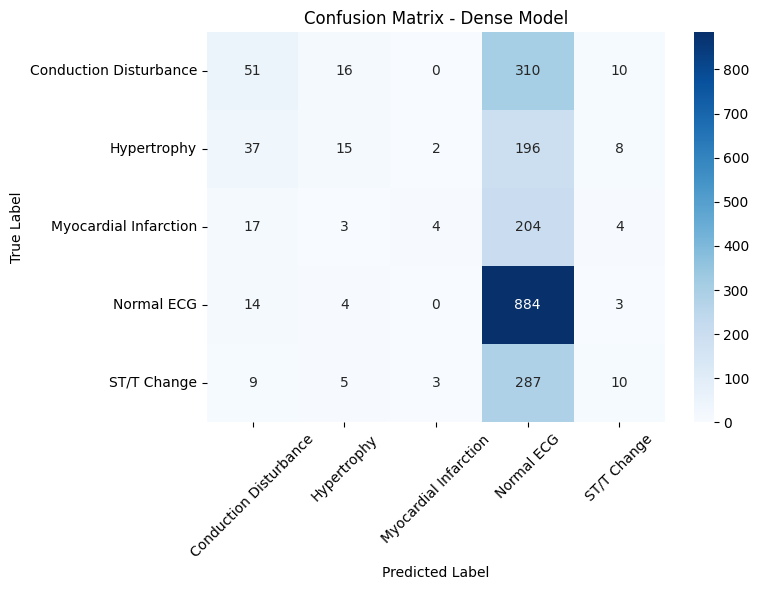

In [28]:
cm = confusion_matrix(y_true, y_pred)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True, 
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Dense Model")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

SMOTE ON DENSE

In [ ]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from imblearn.over_sampling import SMOTE

X = np.array(df['ecg_signal'].tolist(), dtype=np.float32)
y_labels = df['diagnosis'].to_numpy()

X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

le = LabelEncoder()
y_int = le.fit_transform(y_labels)

num_classes = len(le.classes_)
y = to_categorical(y_int, num_classes=num_classes)

train_mask = df['strat_fold'].isin([1,2,3,4,5,6,7,8])
val_mask = df['strat_fold'] == 9
test_mask = df['strat_fold'] == 10

X_train = X[train_mask]
X_val = X[val_mask]
X_test = X[test_mask]

y_train = y[train_mask]
y_val = y[val_mask]
y_test = y[test_mask]

y_train_int = y_int[train_mask]
y_val_int = y_int[val_mask]
y_test_int = y_int[test_mask]

X_train_flat = X_train.reshape(X_train.shape[0], -1).astype(np.float32)
X_val_flat = X_val.reshape(X_val.shape[0], -1).astype(np.float32)
X_test_flat = X_test.reshape(X_test.shape[0], -1).astype(np.float32)

smote = SMOTE(random_state=42)
X_train_smote_flat, y_train_smote_int = smote.fit_resample(X_train_flat, y_train_int)
y_train_smote = to_categorical(y_train_smote_int, num_classes=num_classes)

print("X_train_smote_flat:", X_train_smote_flat.shape)
print("y_train_smote:", y_train_smote.shape)
print("X_val_flat:", X_val_flat.shape)
print("y_val:", y_val.shape)
print("num_classes:", num_classes)

X_train_smote_flat: (35635, 12000)
y_train_smote: (35635, 5)
X_val_flat: (2096, 12000)
y_val: (2096, 5)
num_classes: 5


In [41]:
import tensorflow as tf
from tensorflow.keras import layers, models

tf.keras.backend.clear_session()

model = models.Sequential([
    layers.Input(shape=(X_train_smote_flat.shape[1],)),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5)
]

history = model.fit(
    X_train_smote_flat,
    y_train_smote,
    validation_data=(X_val_flat, y_val),
    epochs=30,
    batch_size=32,
    callbacks=callbacks
)


Epoch 1/30
1114/1114 ━━━━━━━━━━━━━━━━━━━━ 25s 21ms/step - accuracy: 0.5317 - loss: 1.1951 - val_accuracy: 0.3941 - val_loss: 1.5212 - learning_rate: 0.0010
Epoch 2/30
1114/1114 ━━━━━━━━━━━━━━━━━━━━ 23s 21ms/step - accuracy: 0.6609 - loss: 0.8947 - val_accuracy: 0.4074 - val_loss: 1.5130 - learning_rate: 0.0010
Epoch 3/30
1114/1114 ━━━━━━━━━━━━━━━━━━━━ 22s 20ms/step - accuracy: 0.7275 - loss: 0.7352 - val_accuracy: 0.4442 - val_loss: 1.5060 - learning_rate: 0.0010
Epoch 4/30
1114/1114 ━━━━━━━━━━━━━━━━━━━━ 23s 21ms/step - accuracy: 0.7717 - loss: 0.6341 - val_accuracy: 0.4427 - val_loss: 1.5669 - learning_rate: 0.0010
Epoch 5/30
1114/1114 ━━━━━━━━━━━━━━━━━━━━ 22s 20ms/step - accuracy: 0.7988 - loss: 0.5679 - val_accuracy: 0.4308 - val_loss: 1.6036 - learning_rate: 0.0010
Epoch 6/30
1114/1114 ━━━━━━━━━━━━━━━━━━━━ 23s 20ms/step - accuracy: 0.8235 - loss: 0.4965 - val_accuracy: 0.4280 - val_loss: 1.6784 - learning_rate: 0.0010
Epoch 7/30
1114/1114 ━━━━━━━━━━━━━━━━━━━━ 24s 22ms/step - accur

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
                        precision    recall  f1-score   support

Conduction Disturbance       0.37      0.20      0.26       387
           Hypertrophy       0.30      0.17      0.22       258
 Myocardial Infarction       0.17      0.13      0.15       232
            Normal ECG       0.54      0.79      0.64       905
           ST/T Change       0.27      0.21      0.24       314

              accuracy                           0.44      2096
             macro avg       0.33      0.30      0.30      2096
          weighted avg       0.40      0.44      0.40      2096



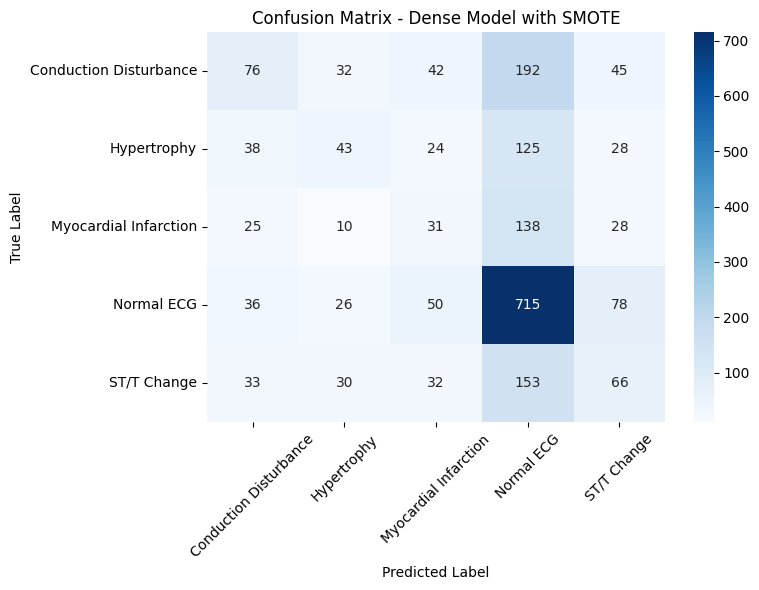

In [43]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_val_flat).argmax(axis=1)
y_true = y_val.argmax(axis=1)

print(classification_report(y_true, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Dense Model with SMOTE")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()